'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


/Users/zhuyi/Desktop/FLARE data/figures/test3_forced_systems_comparison.pdf
/Users/zhuyi/Desktop/FLARE data/figures/test3_forced_systems_comparison.png


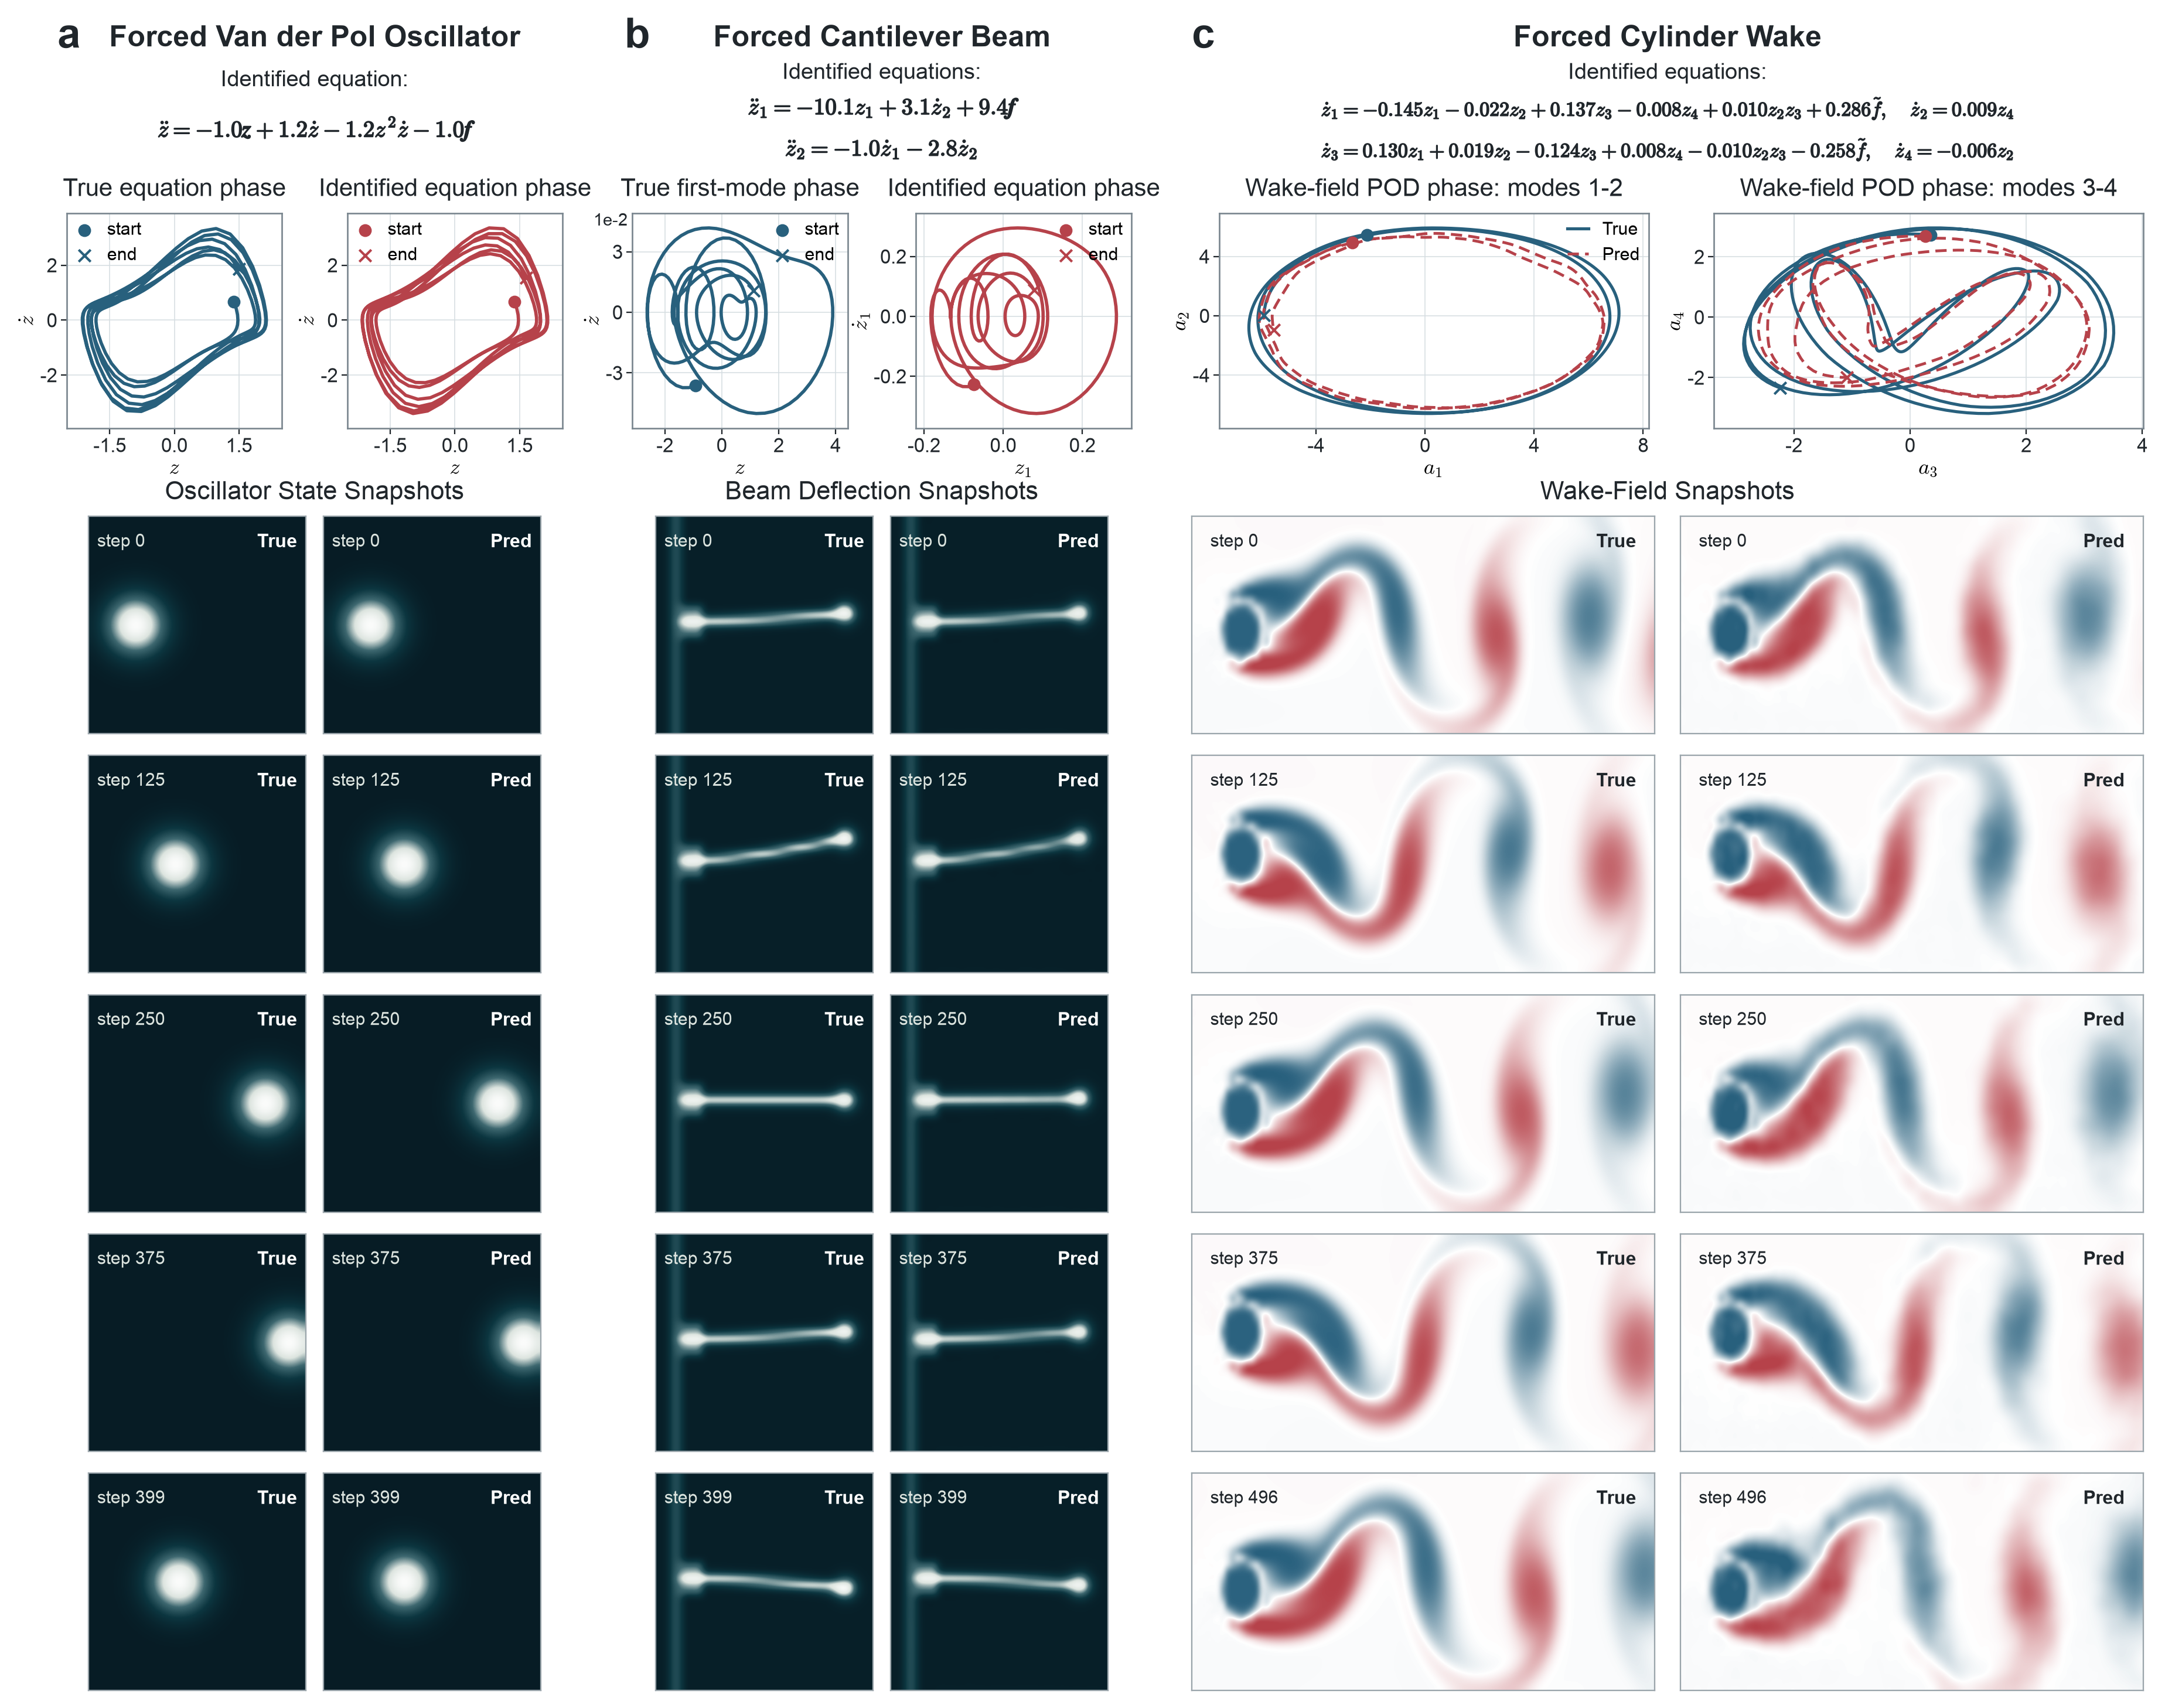

In [1]:
from __future__ import annotations
import re
import json
import sys
from pathlib import Path

import matplotlib as mpl

mpl.use("Agg")

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid


BASE_DIR = Path(r'/Users/zhuyi/Desktop/FLARE data/results')
try:
    OUTPUT_DIR = Path(__file__).resolve().parent
except NameError:
    OUTPUT_DIR = Path.cwd()

PDF_PATH = OUTPUT_DIR / "test3_forced_systems_comparison.pdf"
PNG_PATH = OUTPUT_DIR / "test3_forced_systems_comparison.png"

VDP_DIR = BASE_DIR / "vdp" / "outputs" / "offline_encoder_rollout_duffing_video_sindy_2026_06_10_16_46_25_best"
BEAM_DIR = BASE_DIR / "beam" / "outputs" / "offline_encoder_rollout_duffing_video_sindy_2026_06_12_10_28_39_best"
WAKE_DIR = (
    BASE_DIR
    / "wake"
    / "outputs"
    / "offline_encoder_rollout_cylinder_flow_32x96_window_sindy_2026_06_15_15_14_05_best"
)

BEAM_HELPER_DIR = Path(r"/Users/zhuyi/Desktop/FLARE/beam_latent_q1_compare")
if str(BEAM_HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(BEAM_HELPER_DIR))
import beam_generator as beam  # noqa: E402


TEXT_COLOR = "#20262B"
SPINE_COLOR = "#7B8790"
GRID_COLOR = "#D5DDE1"
ACCENT_BLUE = "#28607D"
ACCENT_RED = "#B6424A"
ACCENT_ORANGE = "#C97928"
ACCENT_GREEN = "#2F6F6D"

VIDEO_CMAP = LinearSegmentedColormap.from_list(
    "paper_dark_teal_video",
    ["#071C25", "#0C3640", "#3E6870", "#DCE4DF", "#FFFFFF"],
)
WAKE_CMAP = LinearSegmentedColormap.from_list(
    "paper_wake_red_blue",
    [(0.00, "#28607D"), (0.50, "#FFFFFF"), (1.00, "#B6424A")],
)

STEP_REQUESTS = [0, 125, 250, 375, 500]

FIGURE_SIZE = (12.4, 10.45)
TITLE_SIZE = 12.0
SUBTITLE_SIZE = 10.0
LABEL_SIZE = 8.8
TICK_SIZE = 8.0
EQUATION_SIZE = 9.4
WAKE_EQUATION_SIZE = 8.15
WAKE_PHASE_SIDE_PAD = 0.004
WAKE_PHASE_INNER_GAP = 0.03
WAKE_PHASE_GROUP_WIDTH_FACTOR = 1.05
PANEL_LETTER_X = 0
PANEL_LETTER_Y = 1.01
PANEL_LETTER_SIZE = 17.0


def configure_mpl() -> None:
    mpl.rcParams.update(
        {
            "font.family": "Arial",
            "mathtext.fontset": "cm",
            "axes.unicode_minus": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "figure.dpi": 160,
            "savefig.dpi": 300,
            "axes.linewidth": 0.65,
        }
    )


def load_npz(path: Path) -> dict[str, np.ndarray]:
    data = np.load(path, allow_pickle=True)
    return {key: np.asarray(data[key]) for key in data.files}


def reshape_video(flat: np.ndarray, shape: tuple[int, int]) -> np.ndarray:
    arr = np.asarray(flat, dtype=float)
    if arr.ndim == 3:
        return arr
    return arr.reshape(arr.shape[0], shape[0], shape[1])


def field_modal_coordinates(true_video: np.ndarray, pred_video: np.ndarray, n_components: int = 4) -> tuple[np.ndarray, np.ndarray]:
    true_flat = true_video.reshape(true_video.shape[0], -1).astype(float)
    pred_flat = pred_video.reshape(pred_video.shape[0], -1).astype(float)
    mean = true_flat.mean(axis=0, keepdims=True)
    centered = true_flat - mean
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    basis = vt[:n_components].T
    true_coord = centered @ basis
    pred_coord = (pred_flat - mean) @ basis
    for i in range(n_components):
        if np.corrcoef(true_coord[:, i], np.linspace(-1, 1, true_coord.shape[0]))[0, 1] < 0:
            true_coord[:, i] *= -1
            pred_coord[:, i] *= -1
    return true_coord, pred_coord


def selected_steps(num_steps: int) -> list[int]:
    return [min(step, num_steps - 1) for step in STEP_REQUESTS]


def style_image_axis(ax: plt.Axes) -> None:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.55)
        spine.set_color("#9AA5AB")


def style_phase_axis(ax: plt.Axes) -> None:
    ax.tick_params(axis="both", labelsize=TICK_SIZE, length=2.4, width=0.55, colors=TEXT_COLOR, pad=1.5)
    ax.grid(True, color=GRID_COLOR, linewidth=0.45, alpha=0.82)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    for spine in ax.spines.values():
        spine.set_linewidth(0.65)
        spine.set_color(SPINE_COLOR)


def add_start_end(ax: plt.Axes, x: np.ndarray, y: np.ndarray, color: str, label: bool = False) -> None:
    ax.scatter(x[0], y[0], s=18, color=color, marker="o", zorder=4, label="start" if label else None)
    ax.scatter(x[-1], y[-1], s=24, color=color, marker="x", linewidths=1.0, zorder=4, label="end" if label else None)


def set_limits_from_curves(ax: plt.Axes, curves: list[tuple[np.ndarray, np.ndarray]]) -> None:
    x_all = np.concatenate([np.asarray(x, dtype=float) for x, _ in curves])
    y_all = np.concatenate([np.asarray(y, dtype=float) for _, y in curves])
    x_pad = 0.08 * max(float(np.ptp(x_all)), 1e-9)
    y_pad = 0.08 * max(float(np.ptp(y_all)), 1e-9)
    ax.set_xlim(float(np.nanmin(x_all) - x_pad), float(np.nanmax(x_all) + x_pad))
    ax.set_ylim(float(np.nanmin(y_all) - y_pad), float(np.nanmax(y_all) + y_pad))


def shrink_axis(ax: plt.Axes, factor: float = 0.88) -> None:
    pos = ax.get_position()
    new_width = pos.width * factor
    new_height = pos.height * factor
    ax.set_position(
        [
            pos.x0 + 0.5 * (pos.width - new_width),
            pos.y0 + 0.5 * (pos.height - new_height),
            new_width,
            new_height,
        ]
    )


def scale_axis(ax: plt.Axes, width_factor: float = 1.0, height_factor: float = 1.0) -> None:
    pos = ax.get_position()
    new_width = pos.width * width_factor
    new_height = pos.height * height_factor
    ax.set_position(
        [
            pos.x0 + 0.5 * (pos.width - new_width),
            pos.y0 + 0.5 * (pos.height - new_height),
            new_width,
            new_height,
        ]
    )


def shift_axis(ax: plt.Axes, dx: float = 0.0, dy: float = 0.0) -> None:
    pos = ax.get_position()
    ax.set_position([pos.x0 + dx, pos.y0 + dy, pos.width, pos.height])


def align_second_row_axes(axis_groups: list[list[plt.Axes]], wake_reference_right: float | None = None) -> None:
    if len(axis_groups) != 3:
        return
    all_axes = [ax for group in axis_groups for ax in group]
    if not all_axes:
        return
    fig = all_axes[0].figure
    fig.canvas.draw()

    square_axes = axis_groups[0] + axis_groups[1]
    target_top = float(np.mean([ax.get_position().y1 for ax in square_axes]))
    target_height = 1.03 * float(np.mean([ax.get_position().height for ax in square_axes]))

    for ax in square_axes:
        pos = ax.get_position()
        center_x = pos.x0 + 0.5 * pos.width
        ax.set_position([center_x - 0.5 * target_height, target_top - target_height, target_height, target_height])

    wake_axes = axis_groups[2]
    if len(wake_axes) == 2:
        positions = [ax.get_position() for ax in wake_axes]
        current_left = min(pos.x0 for pos in positions) - WAKE_PHASE_SIDE_PAD
        current_right = max(pos.x1 for pos in positions) + WAKE_PHASE_SIDE_PAD
        right = current_right if wake_reference_right is None else wake_reference_right
        group_width = (current_right - current_left) * WAKE_PHASE_GROUP_WIDTH_FACTOR
        left = right - group_width
        panel_width = 0.5 * (group_width - WAKE_PHASE_INNER_GAP)
        wake_axes[0].set_position([left, target_top - target_height, panel_width, target_height])
        wake_axes[1].set_position([left + panel_width + WAKE_PHASE_INNER_GAP, target_top - target_height, panel_width, target_height])

NUMBER_PATTERN = re.compile(
    r"\d+(?:\.\d+)?"
)


def normal_weight_math_numbers(expression: str) -> str:
    return NUMBER_PATTERN.sub(
        lambda match: rf"\mathrm{{{match.group(0)}}}",
        expression,
    )

def draw_equation_text(
    ax: plt.Axes,
    x: float,
    y: float,
    text: str,
    *,
    fontsize: float,
    ha: str = "center",
    va: str = "center",
) -> None:
    if text.startswith("$") and text.endswith("$"):
        expression = text[1:-1]
        expression = normal_weight_math_numbers(expression)

        text = r"$\boldsymbol{" + expression + "}$"

    ax.text(
        x,
        y,
        text,
        ha=ha,
        va=va,
        fontsize=fontsize,
        color=TEXT_COLOR,
        fontweight="bold",
        path_effects=[
            pe.withStroke(
                linewidth=0.44,
                foreground=TEXT_COLOR,
            )
        ],
        transform=ax.transAxes,
    )


def add_column_header(
    ax: plt.Axes,
    title: str,
    equations: list[str],
    equation_size: float = EQUATION_SIZE,
    y_offset: float = 0.0,
    panel_letter: str | None = None,
) -> None:
    ax.axis("off")
    if panel_letter is not None:
        ax.text(
            PANEL_LETTER_X,
            PANEL_LETTER_Y,
            panel_letter,
            ha="left",
            va="top",
            fontsize=PANEL_LETTER_SIZE,
            fontweight="bold",
            color=TEXT_COLOR,
            transform=ax.transAxes,
            clip_on=False,
        )
    ax.text(
        0.5,
        0.96,
        title,
        ha="center",
        va="top",
        fontsize=TITLE_SIZE,
        fontweight="bold",
        color=TEXT_COLOR,
        transform=ax.transAxes,
    )
    label_y = (0.58 if len(equations) == 1 else 0.70) + y_offset
    ax.text(
        0.5,
        label_y,
        "Identified equation:" if len(equations) == 1 else "Identified equations:",
        ha="center",
        va="center",
        fontsize=EQUATION_SIZE - 0.4,
        color=TEXT_COLOR,
        transform=ax.transAxes,
    )
    y = (0.25 if len(equations) == 1 else 0.46) + y_offset
    for line in equations:
        draw_equation_text(
            ax,
            0.5,
            y,
            line,
            ha="center",
            va="center",
            fontsize=equation_size,
        )
        y -= 0.28


def render_video_panel(
    ax: plt.Axes,
    frame: np.ndarray,
    *,
    kind: str,
    label: str,
    step: int,
    norm: TwoSlopeNorm | None = None,
) -> None:
    if kind in {"vdp", "beam"}:
        ax.imshow(frame, cmap=VIDEO_CMAP, vmin=0.0, vmax=1.0, origin="lower", interpolation="bicubic")
        ax.set_facecolor("#071C25")
    else:
        ax.imshow(frame, cmap=WAKE_CMAP, norm=norm, origin="lower", interpolation="bicubic", aspect="auto")
        ax.set_facecolor("white")
    style_image_axis(ax)
    ax.text(
        0.96,
        0.92,
        label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=7.6,
        color="white" if kind in {"vdp", "beam"} else TEXT_COLOR,
        fontweight="bold",
    )
    ax.text(
        0.04,
        0.92,
        f"step {step}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7.2,
        color="#DCE4DF" if kind in {"vdp", "beam"} else TEXT_COLOR,
    )


def add_snapshot_rows(
    fig: plt.Figure,
    parent,
    data: dict[str, np.ndarray],
    *,
    kind: str,
    shape: tuple[int, int],
    title: str,
) -> list[plt.Axes]:
    true_video = reshape_video(data["p_true"], shape)
    pred_video = reshape_video(data["p_pred"], shape)
    steps = selected_steps(true_video.shape[0])
    if kind == "wake":
        values = np.concatenate([true_video.reshape(true_video.shape[0], -1), pred_video.reshape(pred_video.shape[0], -1)], axis=0)
        vmin, vmax = np.nanpercentile(values, [0.5, 99.5])
        norm = TwoSlopeNorm(vmin=float(vmin), vcenter=0.5, vmax=float(vmax))
        wspace = 0.055
    else:
        norm = None
        wspace = 0.070
    block = GridSpecFromSubplotSpec(2, 1, subplot_spec=parent, height_ratios=[0.040, 1.0], hspace=0.0)
    title_ax = fig.add_subplot(block[0, 0])
    title_ax.axis("off")
    title_ax.text(
        0.5,
        0.50,
        title,
        ha="center",
        va="center",
        fontsize=SUBTITLE_SIZE + 0.3,
        color=TEXT_COLOR,
    )
    grid = GridSpecFromSubplotSpec(len(steps), 2, subplot_spec=block[1, 0], hspace=0.10, wspace=wspace)
    axes: list[plt.Axes] = []
    for row, step in enumerate(steps):
        for col, key in enumerate(("True", "Pred")):
            ax = fig.add_subplot(grid[row, col])
            axes.append(ax)
            if kind in {"vdp", "beam"}:
                ax.set_anchor("E" if col == 0 else "W")
            frame = true_video[step] if key == "True" else pred_video[step]
            render_video_panel(ax, frame, kind=kind, label=key, step=step, norm=norm)
    return axes


def draw_vdp_bottom(fig: plt.Figure, parent, data: dict[str, np.ndarray]) -> list[plt.Axes]:
    t = np.asarray(data["t"], dtype=float)
    forcing = np.asarray(data["forcing_raw"], dtype=float).reshape(-1)
    z0 = np.asarray(data["z0"], dtype=float).reshape(1)
    v0 = np.asarray(data["v0"], dtype=float).reshape(1)
    true_z, true_v = rk4_second_order(vdp_true_accel, t, z0, v0, forcing)
    pred_z, pred_v = rk4_second_order(vdp_identified_accel, t, z0, v0, forcing)
    grid = GridSpecFromSubplotSpec(1, 2, subplot_spec=parent, wspace=0.2)
    ax_true = fig.add_subplot(grid[0, 0])
    ax_pred = fig.add_subplot(grid[0, 1])
    draw_vdp_equation_phase(ax_true, true_z[:, 0], true_v[:, 0], "True equation phase", ACCENT_BLUE, legend_loc="upper left")
    draw_vdp_equation_phase(ax_pred, pred_z[:, 0], pred_v[:, 0], "Identified equation phase", ACCENT_RED, legend_loc="upper left")
    xlim = (
        min(ax_true.get_xlim()[0], ax_pred.get_xlim()[0]),
        max(ax_true.get_xlim()[1], ax_pred.get_xlim()[1]),
    )
    ylim = (
        min(ax_true.get_ylim()[0], ax_pred.get_ylim()[0]),
        max(ax_true.get_ylim()[1], ax_pred.get_ylim()[1]),
    )
    ax_true.set_xlim(*xlim)
    ax_pred.set_xlim(*xlim)
    ax_true.set_ylim(*ylim)
    ax_pred.set_ylim(*ylim)
    shrink_axis(ax_true, 0.90)
    shrink_axis(ax_pred, 0.90)
    return [ax_true, ax_pred]


def regenerate_beam_first_mode(force_raw: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    spec_path = BEAM_HELPER_DIR / "sample_specs.json"
    specs = json.loads(spec_path.read_text(encoding="utf-8"))
    best: tuple[float, dict[str, object], dict[str, np.ndarray]] | None = None
    for spec in specs:
        if spec["split"] != "test":
            continue
        preferred_force_type = "smooth_plateau" if int(spec["global_index"]) == 1 else None
        seq, _ = beam.integrate_one_sequence(
            seq_len=beam.SEQ_LEN,
            t_end=beam.T_END,
            t_burn=beam.T_BURN,
            rng=np.random.default_rng(int(spec["seed"])),
            preferred_force_type=preferred_force_type,
        )
        err = float(np.max(np.abs(force_raw.reshape(-1) - seq["f"].astype(float))))
        if best is None or err < best[0]:
            best = (err, spec, seq)
    if best is None:
        raise RuntimeError("No matching beam test specification was found.")
    return best[2]["q"][:, 0].astype(float), best[2]["qdot"][:, 0].astype(float)


def interp_force(t: np.ndarray, forcing: np.ndarray, tau: float) -> float:
    return float(np.interp(float(tau), np.asarray(t, dtype=float), np.asarray(forcing, dtype=float).reshape(-1)))


def rk4_first_order(
    rhs,
    t: np.ndarray,
    y0: np.ndarray,
    forcing: np.ndarray,
) -> np.ndarray:
    t = np.asarray(t, dtype=float)
    y = np.zeros((len(t), len(y0)), dtype=float)
    y[0] = np.asarray(y0, dtype=float)
    for i in range(len(t) - 1):
        ti = float(t[i])
        dt = float(t[i + 1] - t[i])
        yi = y[i]
        k1 = rhs(ti, yi, t, forcing)
        k2 = rhs(ti + 0.5 * dt, yi + 0.5 * dt * k1, t, forcing)
        k3 = rhs(ti + 0.5 * dt, yi + 0.5 * dt * k2, t, forcing)
        k4 = rhs(ti + dt, yi + dt * k3, t, forcing)
        y[i + 1] = yi + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    return y


def rk4_second_order(
    accel,
    t: np.ndarray,
    z0: np.ndarray,
    v0: np.ndarray,
    forcing: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    y0 = np.concatenate([np.asarray(z0, dtype=float), np.asarray(v0, dtype=float)])
    dim = len(z0)

    def rhs(tau: float, state: np.ndarray, tt: np.ndarray, ff: np.ndarray) -> np.ndarray:
        z = state[:dim]
        v = state[dim:]
        return np.concatenate([v, accel(tau, z, v, tt, ff)])

    state = rk4_first_order(rhs, t, y0, forcing)
    return state[:, :dim], state[:, dim:]


def vdp_true_accel(tau: float, z: np.ndarray, v: np.ndarray, t: np.ndarray, forcing: np.ndarray) -> np.ndarray:
    f = interp_force(t, forcing, tau)
    return np.asarray([-1.0 * z[0] + 1.2 * v[0] - 1.2 * z[0] * z[0] * v[0] - 1.0 * f], dtype=float)


def vdp_identified_accel(tau: float, z: np.ndarray, v: np.ndarray, t: np.ndarray, forcing: np.ndarray) -> np.ndarray:
    f = interp_force(t, forcing, tau)
    return np.asarray([-1.0053532 * z[0] + 1.2154145 * v[0] - 1.1951336 * z[0] * z[0] * v[0] - 1.0186491 * f], dtype=float)


def beam_identified_accel(tau: float, z: np.ndarray, v: np.ndarray, t: np.ndarray, forcing: np.ndarray) -> np.ndarray:
    f = interp_force(t, forcing, tau)
    return np.asarray(
        [
            -10.0526 * z[0] + 3.080209 * v[1] + 9.3553829 * f,
            -1.0270059 * v[0] - 2.7992847 * v[1],
        ],
        dtype=float,
    )


def draw_beam_bottom(fig: plt.Figure, parent, data: dict[str, np.ndarray]) -> list[plt.Axes]:
    q1, q1dot = regenerate_beam_first_mode(np.asarray(data["forcing_raw"], dtype=float))
    t = np.asarray(data["t"], dtype=float)
    forcing = np.asarray(data["forcing_raw"], dtype=float).reshape(-1)
    z_pred, zdot_pred = rk4_second_order(
        beam_identified_accel,
        t,
        np.asarray(data["z0"], dtype=float).reshape(2),
        np.asarray(data["v0"], dtype=float).reshape(2),
        forcing,
    )
    q1_plot = 100.0 * q1
    q1dot_plot = 100.0 * q1dot

    grid = GridSpecFromSubplotSpec(1, 2, subplot_spec=parent, wspace=0.23)
    axes = [fig.add_subplot(grid[0, i]) for i in range(2)]

    axes[0].plot(q1_plot, q1dot_plot, color=ACCENT_BLUE, lw=1.35)
    add_start_end(axes[0], q1_plot, q1dot_plot, ACCENT_BLUE, label=True)
    axes[0].set_title("True first-mode phase", fontsize=SUBTITLE_SIZE, color=TEXT_COLOR, pad=7)

    axes[1].plot(z_pred[:, 0], zdot_pred[:, 0], color=ACCENT_RED, lw=1.35)
    add_start_end(axes[1], z_pred[:, 0], zdot_pred[:, 0], ACCENT_RED, label=True)
    axes[1].xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[1].yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[1].set_title(r"Identified equation phase", fontsize=SUBTITLE_SIZE, color=TEXT_COLOR, pad=7)

    for idx, ax in enumerate(axes):
        style_phase_axis(ax)
        ax.set_xlabel(r"$z_1$" if idx == 1 else r"$z$", fontsize=LABEL_SIZE, labelpad=1)
        ax.set_ylabel(r"$\dot{z}_1$" if idx == 1 else r"$\dot{z}$", fontsize=LABEL_SIZE, labelpad=1)
        ax.set_box_aspect(1)
        if idx == 0:
            ax.text(
                -0.18,
                1.00,
                "1e-2",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=TICK_SIZE - 1.0,
                color=TEXT_COLOR,
                clip_on=False,
            )
        ax.legend(
            frameon=False,
            fontsize=7.2,
            loc="upper right",
            handlelength=1.0,
            borderaxespad=0.1,
        )
    set_limits_from_curves(axes[0], [(q1_plot, q1dot_plot)])
    set_limits_from_curves(axes[1], [(z_pred[:, 0], zdot_pred[:, 0])])
    shrink_axis(axes[0], 0.90)
    shrink_axis(axes[1], 0.90)
    return axes


def draw_equation_phase(
    ax: plt.Axes,
    x: np.ndarray,
    y: np.ndarray,
    title: str,
    xlabel: str,
    ylabel: str,
    color: str,
    legend_loc: str = "upper right",
) -> None:
    ax.plot(x, y, color=color, lw=1.35)
    add_start_end(ax, x, y, color, label=True)
    style_phase_axis(ax)
    ax.set_title(title, fontsize=SUBTITLE_SIZE, color=TEXT_COLOR, pad=7)
    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE, labelpad=1)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE, labelpad=1)
    set_limits_from_curves(ax, [(x, y)])
    ax.legend(frameon=False, fontsize=7.2, loc=legend_loc, handlelength=1.0, borderaxespad=0.1)


def draw_vdp_equation_phase(
    ax: plt.Axes,
    z: np.ndarray,
    zdot: np.ndarray,
    title: str,
    color: str,
    legend_loc: str = "upper left",
) -> None:
    draw_equation_phase(ax, z, zdot, title, r"$z$", r"$\dot{z}$", color, legend_loc=legend_loc)
    ax.set_box_aspect(1)


def draw_wake_response_phase(
    ax: plt.Axes,
    true_xy: tuple[np.ndarray, np.ndarray],
    pred_xy: tuple[np.ndarray, np.ndarray],
    title: str,
    xlabel: str,
    ylabel: str,
    *,
    show_legend: bool = False,
) -> None:
    ax.plot(true_xy[0], true_xy[1], color=ACCENT_BLUE, lw=1.25, label="True")
    ax.plot(pred_xy[0], pred_xy[1], color=ACCENT_RED, lw=1.15, ls=(0, (4, 2.2)), label="Pred")
    add_start_end(ax, true_xy[0], true_xy[1], ACCENT_BLUE)
    add_start_end(ax, pred_xy[0], pred_xy[1], ACCENT_RED)
    style_phase_axis(ax)
    ax.set_title(title, fontsize=SUBTITLE_SIZE, color=TEXT_COLOR, pad=7)
    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE, labelpad=1)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE, labelpad=1)
    set_limits_from_curves(ax, [true_xy, pred_xy])
    if show_legend:
        ax.legend(
            frameon=False,
            fontsize=7.2,
            loc="upper right",
            handlelength=1.2,
            borderaxespad=0.1,
        )


def draw_wake_bottom(fig: plt.Figure, parent, data: dict[str, np.ndarray]) -> list[plt.Axes]:
    true_video = reshape_video(data["p_true"], (32, 96))
    pred_video = reshape_video(data["p_pred"], (32, 96))
    true_z, pred_z = field_modal_coordinates(true_video, pred_video, 4)
    grid = GridSpecFromSubplotSpec(1, 2, subplot_spec=parent, wspace=0.14)
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    draw_wake_response_phase(
        ax1,
        (true_z[:, 0], true_z[:, 1]),
        (pred_z[:, 0], pred_z[:, 1]),
        "Wake-field POD phase: modes 1-2",
        r"$a_1$",
        r"$a_2$",
        show_legend=True,
    )
    draw_wake_response_phase(
        ax2,
        (true_z[:, 2], true_z[:, 3]),
        (pred_z[:, 2], pred_z[:, 3]),
        "Wake-field POD phase: modes 3-4",
        r"$a_3$",
        r"$a_4$",
    )
    scale_axis(ax1, width_factor=0.80, height_factor=0.90)
    scale_axis(ax2, width_factor=0.80, height_factor=0.90)
    return [ax1, ax2]


def build_figure(save: bool = True, show: bool = False) -> None:
    configure_mpl()
    systems = [
        {
            "kind": "vdp",
            "title": "Forced Van der Pol Oscillator",
            "data": load_npz(VDP_DIR / "offline_prediction_vdp_001.npz"),
            "shape": (32, 32),
            "snapshot_title": "Oscillator State Snapshots",
            "equations": [
                r"$\ddot{z}=-1.0z+1.2\dot{z}-1.2z^2\dot{z}-1.0f$",
            ],
        },
        {
            "kind": "beam",
            "title": "Forced Cantilever Beam",
            "data": load_npz(BEAM_DIR / "offline_prediction_beam_001.npz"),
            "shape": (32, 32),
            "snapshot_title": "Beam Deflection Snapshots",
            "equations": [
                r"$\ddot{z}_1=-10.1z_1+3.1\dot{z}_2+9.4f$",
                r"$\ddot{z}_2=-1.0\dot{z}_1-2.8\dot{z}_2$",
            ],
        },
        {
            "kind": "wake",
            "title": "Forced Cylinder Wake",
            "data": load_npz(WAKE_DIR / "offline_prediction_osc_cylinder_001.npz"),
            "shape": (32, 96),
            "snapshot_title": "Wake-Field Snapshots",
            "equations": [
                r"$\dot{z}_1=-0.145z_1-0.022z_2+0.137z_3-0.008z_4+0.010z_2z_3+0.286\tilde{f},\quad \dot{z}_2=0.009z_4$",
                r"$\dot{z}_3=0.130z_1+0.019z_2-0.124z_3+0.008z_4-0.010z_2z_3-0.258\tilde{f},\quad \dot{z}_4=-0.006z_2$",
            ],
        },
    ]

    fig = plt.figure(figsize=FIGURE_SIZE, constrained_layout=False)
    outer = GridSpec(
        1,
        3,
        figure=fig,
        width_ratios=[1.0, 1.0, 1.85],
        left=0.035,
        right=0.992,
        bottom=0.055,
        top=0.965,
        wspace=0.08,
    )

    phase_axis_groups: list[list[plt.Axes]] = []
    wake_snapshot_axes: list[plt.Axes] = []
    for col, spec in enumerate(systems):
        inner = GridSpecFromSubplotSpec(
            3,
            1,
            subplot_spec=outer[col],
            height_ratios=[0.62, 1.28, 5.15],
            hspace=0.0,
        )
        header_ax = fig.add_subplot(inner[0, 0])
        eq_size = WAKE_EQUATION_SIZE if spec["kind"] == "wake" else EQUATION_SIZE
        header_y_offset = 0.0 if col == 0 else -0.07
        add_column_header(
            header_ax,
            spec["title"],
            spec["equations"],
            eq_size,
            y_offset=header_y_offset,
            panel_letter="abc"[col],
        )
        if spec["kind"] == "vdp":
            phase_axis_groups.append(draw_vdp_bottom(fig, inner[1, 0], spec["data"]))
        elif spec["kind"] == "beam":
            phase_axis_groups.append(draw_beam_bottom(fig, inner[1, 0], spec["data"]))
        else:
            phase_axis_groups.append(draw_wake_bottom(fig, inner[1, 0], spec["data"]))
        snapshot_axes = add_snapshot_rows(
            fig,
            inner[2, 0],
            spec["data"],
            kind=spec["kind"],
            shape=spec["shape"],
            title=spec["snapshot_title"],
        )
        if spec["kind"] == "wake":
            wake_snapshot_axes = snapshot_axes

    fig.canvas.draw()
    wake_reference_right = max((ax.get_position().x1 for ax in wake_snapshot_axes), default=None)
    align_second_row_axes(phase_axis_groups, wake_reference_right=wake_reference_right)

    if save:
        fig.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.04)
        fig.savefig(PNG_PATH, dpi=300, bbox_inches="tight", pad_inches=0.04)
        print(PDF_PATH)
        print(PNG_PATH)
    if show:
        try:
            from io import BytesIO
            from IPython.display import Image, display

            buf = BytesIO()
            fig.savefig(buf, format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)
            buf.seek(0)
            display(Image(data=buf.getvalue()))
        except Exception:
            plt.show()
    else:
        plt.close(fig)


if __name__ == "__main__":
    build_figure(save=True, show=True)